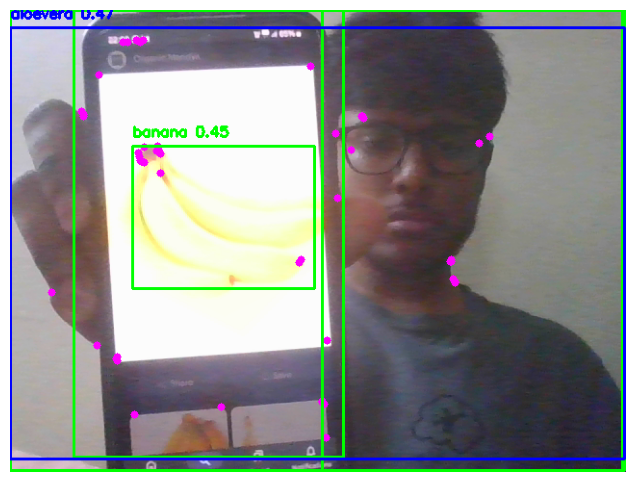

🔍 ORB matched coordinates (top 10): [(141, 138), (139, 139), (327, 442), (110, 362), (301, 262), (179, 422), (324, 404), (462, 282), (89, 347), (340, 193)]



In [ ]:
import cv2
import time
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, clear_output

# Load models
yolo_basic = YOLO("yolov8n.pt")
yolo_trained = YOLO(r"C:\Users\91939\OneDrive\Desktop\python\data\runs\detect\retry_aloevera_banana\weights\best.pt")

# ORB setup
ref_img_path = r'C:\Users\91939\OneDrive\Desktop\python\orb_matcher\reference.jpg'
ref_img = cv2.imread(ref_img_path, cv2.IMREAD_GRAYSCALE)
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(ref_img, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Setup camera
cap = cv2.VideoCapture(0)
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))
start_time = time.time()

print("📷 Starting camera for 25 seconds...")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to grab frame.")
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    annotated = frame.copy()

    # Track best result
    best_model = "None"
    best_score = 0
    best_time = 0

    # ORB Matching
    t0 = time.time()
    kp2, des2 = orb.detectAndCompute(gray, None)
    orb_matches = []
    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        orb_matches = [(int(kp2[m.trainIdx].pt[0]), int(kp2[m.trainIdx].pt[1])) for m in matches[:50]]
    orb_score = min(1.0, len(orb_matches)/50)
    orb_time = time.time() - t0

    # Draw ORB keypoints (violet)
    for (x, y) in orb_matches:
        cv2.circle(annotated, (x, y), 4, (255, 0, 255), -1)

    # Check if ORB is best
    if orb_score > best_score:
        best_score = orb_score
        best_model = "ORB"
        best_time = orb_time

    print(f"🔍 ORB matched coordinates (top 10): {orb_matches[:10]}")

    # YOLO BASIC Detection
    t0 = time.time()
    results_basic = yolo_basic(frame)
    t_basic = time.time() - t0
    for result in results_basic:
        for box in result.boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green
            cv2.putText(annotated, f"{yolo_basic.names[cls]} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            if conf > best_score:
                best_score = conf
                best_model = "YOLO Basic"
                best_time = t_basic

    # YOLO TRAINED Detection
    t0 = time.time()
    results_trained = yolo_trained(frame)
    t_trained = time.time() - t0
    for result in results_trained:
        for box in result.boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            name = ['aloevera', 'banana'][cls] if cls < 2 else f"Class {cls}"
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Blue
            cv2.putText(annotated, f"{name} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

            if conf > best_score:
                best_score = conf
                best_model = "YOLO Trained"
                best_time = t_trained

    # Final Output
    print(f"\n📌 Best: {best_model} ({best_score:.2f}) | Time: {best_time:.2f}s")
    print(f"💬 YOLO Basic: {results_basic[0].verbose()}")
    print(f"💬 YOLO Trained: {results_trained[0].verbose()}\n")

    # Show frame
    clear_output(wait=True)
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.clear()
    ax.imshow(annotated_rgb)
    ax.axis('off')
    display(fig)
    plt.pause(0.001)

    if time.time() - start_time > 25:
        print("⏱️ 25 seconds elapsed.")
        break

cap.release()
plt.ioff()
plt.close()


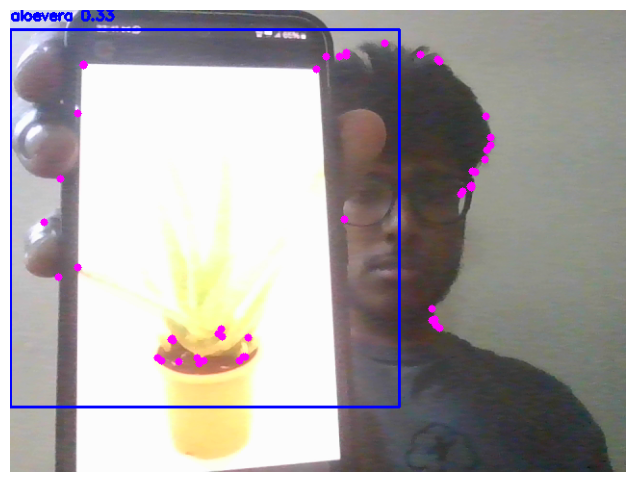

⏱️ 25 seconds elapsed.

🎯 FINAL SUMMARY (After 25s):
📌 Overall Best: ORB (1.00) | Coordinates: (61, 107)
🟣 ORB Highest Score: 1.00
🟢 YOLO Basic Highest Confidence: 0.32
🔵 YOLO Trained Highest Confidence: 0.70


In [4]:
import cv2
import time
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, clear_output

# Load models
yolo_basic = YOLO("yolov8n.pt")
yolo_trained = YOLO(r"C:\Users\91939\OneDrive\Desktop\python\data\runs\detect\retry_aloevera_banana\weights\best.pt")

# ORB setup
ref_img_path = r'C:\Users\91939\OneDrive\Desktop\python\orb_matcher\reference.jpg'
ref_img = cv2.imread(ref_img_path, cv2.IMREAD_GRAYSCALE)
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(ref_img, None)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Setup camera
cap = cv2.VideoCapture(0)
plt.ion()
fig, ax = plt.subplots(figsize=(10, 6))
start_time = time.time()

# Tracking variables
overall_best_model = "None"
overall_best_score = 0
overall_best_coords = None
orb_highest = 0
basic_highest = 0
trained_highest = 0

print("📷 Starting camera for 25 seconds...")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to grab frame.")
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    annotated = frame.copy()

    # ORB Matching
    kp2, des2 = orb.detectAndCompute(gray, None)
    orb_matches = []
    if des1 is not None and des2 is not None:
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        orb_matches = [(int(kp2[m.trainIdx].pt[0]), int(kp2[m.trainIdx].pt[1])) for m in matches[:50]]
    orb_score = min(1.0, len(orb_matches) / 50)

    for (x, y) in orb_matches:
        cv2.circle(annotated, (x, y), 4, (255, 0, 255), -1)

    if orb_score > orb_highest:
        orb_highest = orb_score

    # YOLO BASIC Detection (Only "potted plant")
    results_basic = yolo_basic(frame)
    yolo_basic_best_conf = 0
    yolo_basic_best_coords = None
    for result in results_basic:
        for box in result.boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            name = yolo_basic.names[cls]
            if name.lower().replace(" ", "") == 'pottedplant':
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(annotated, f"{name} {conf:.2f}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                if conf > yolo_basic_best_conf:
                    yolo_basic_best_conf = conf
                    yolo_basic_best_coords = (x1, y1, x2, y2)

    if yolo_basic_best_conf > basic_highest:
        basic_highest = yolo_basic_best_conf

    # YOLO TRAINED Detection
    results_trained = yolo_trained(frame)
    yolo_trained_best_conf = 0
    yolo_trained_best_coords = None
    for result in results_trained:
        for box in result.boxes:
            conf = float(box.conf[0])
            cls = int(box.cls[0])
            name = ['aloevera', 'banana'][cls] if cls < 2 else f"Class {cls}"
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(annotated, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(annotated, f"{name} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
            if conf > yolo_trained_best_conf:
                yolo_trained_best_conf = conf
                yolo_trained_best_coords = (x1, y1, x2, y2)

    if yolo_trained_best_conf > trained_highest:
        trained_highest = yolo_trained_best_conf

    # FINAL DECISION LOGIC (Strict Priority)
    if yolo_trained_best_conf >= 0.5:
        current_best_model = "YOLO Trained"
        current_best_score = yolo_trained_best_conf
        current_best_coords = yolo_trained_best_coords
    elif yolo_trained_best_conf < 0.5 and yolo_basic_best_conf >= 0.8:
        current_best_model = "YOLO Trained"
        current_best_score = yolo_trained_best_conf
        current_best_coords = yolo_trained_best_coords
    elif yolo_trained_best_conf > 0.5 and yolo_basic_best_conf <= 0.8:
        current_best_model = "YOLO Basic"
        current_best_score = yolo_basic_best_conf
        current_best_coords = yolo_basic_best_coords
    else:
        current_best_model = "ORB"
        current_best_score = orb_score
        current_best_coords = orb_matches[0] if orb_matches else None

    # Update overall best
    if current_best_score > overall_best_score:
        overall_best_model = current_best_model
        overall_best_score = current_best_score
        overall_best_coords = current_best_coords

    # Display live feedback
    print(f"\n📌 Best: {current_best_model} ({current_best_score:.2f})")
    if current_best_model == "ORB":
        print(f"🔍 ORB matched coordinates (top 10): {orb_matches[:10]}")
    print(f"💬 YOLO Basic: {results_basic[0].verbose()}")
    print(f"💬 YOLO Trained: {results_trained[0].verbose()}\n")

    clear_output(wait=True)
    ax.clear()
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    display(fig)
    plt.pause(0.001)

    if time.time() - start_time > 25:
        print("⏱️ 25 seconds elapsed.")
        break

# Final Summary
print(f"\n🎯 FINAL SUMMARY (After 25s):")
print(f"📌 Overall Best: {overall_best_model} ({overall_best_score:.2f}) | Coordinates: {overall_best_coords}")
print(f"🟣 ORB Highest Score: {orb_highest:.2f}")
print(f"🟢 YOLO Basic Highest Confidence: {basic_highest:.2f}")
print(f"🔵 YOLO Trained Highest Confidence: {trained_highest:.2f}")

cap.release()
plt.ioff()
plt.close()
